# K-Nearest Neighbors from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

K-Nearest Neighbors (KNN) is a **non-parametric, instance-based** classification algorithm. It makes predictions by:

1. Computing the distance from a test point to every training point
2. Selecting the **k nearest** neighbors
3. Returning the **majority class** among those neighbors

We use **Euclidean distance**:

$$d(x_1, x_2) = \sqrt{\sum_{i=1}^{n}(x_{1,i} - x_{2,i})^2}$$

KNN has no training phase as all computation happens at prediction time.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.supervised_learning.knn import KNN
from rice_ml.processing.metrics import accuracy_score, confusion_matrix
from rice_ml.processing.preprocessing import StandardScaler

## Loading and Exploring the Dataset

We use the **Wine dataset** — 178 wine samples described by 13 chemical features (alcohol, malic acid, ash, etc.), classified into 3 wine cultivars. 

In [22]:
data = load_wine()
X, y = data.data, data.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {data.target_names}")
print(f"Class distribution: {np.bincount(y)}")

Dataset shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Class distribution: [59 71 48]


## Preprocessing and Train/Test Split

In [23]:
X_train, X_test, y_train, y_test = sklearn_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 142
Test samples: 36


## Training and Evaluation Across Different k Values

Choosing the right **k** is critical:
- Small k → low bias, high variance (overfitting)
- Large k → high bias, low variance (underfitting)

Crucial to compare accuracy across multiple values of k.

In [24]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
accuracies = []

for k in k_values:
    model = KNN(k=k).fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"k = {k:2d} | Accuracy = {acc:.4f}")

k =  1 | Accuracy = 0.9722
k =  3 | Accuracy = 0.9722
k =  5 | Accuracy = 0.9722
k =  7 | Accuracy = 1.0000
k =  9 | Accuracy = 1.0000
k = 11 | Accuracy = 1.0000
k = 15 | Accuracy = 1.0000
k = 21 | Accuracy = 1.0000


## Visualizing Accuracy vs k

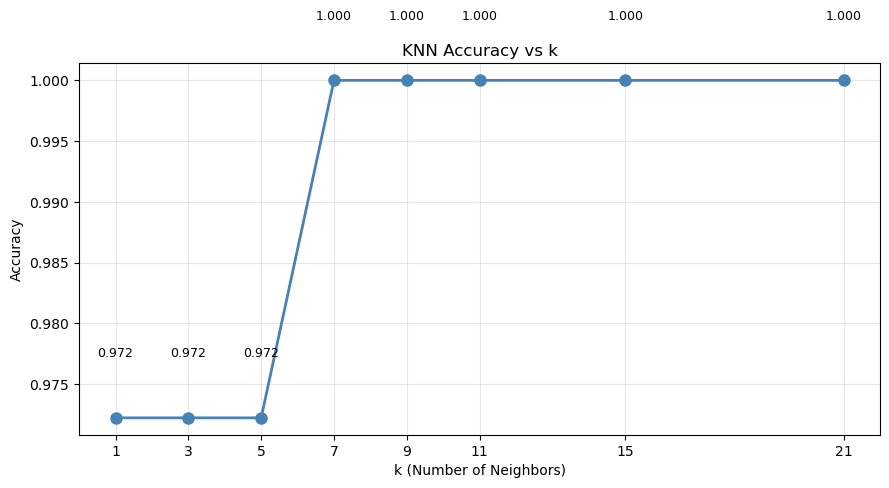

In [25]:
plt.figure(figsize=(9, 5))
plt.plot(k_values, accuracies, marker='o', linewidth=2,
         markersize=8, color='steelblue')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
for k, acc in zip(k_values, accuracies):
    plt.text(k, acc + 0.005, f'{acc:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Decision Boundary Visualization (using 2 features)

To visualize how KNN separates classes, we will train it on just the first two features (sepal length and sepal width) and plot the decision boundary.

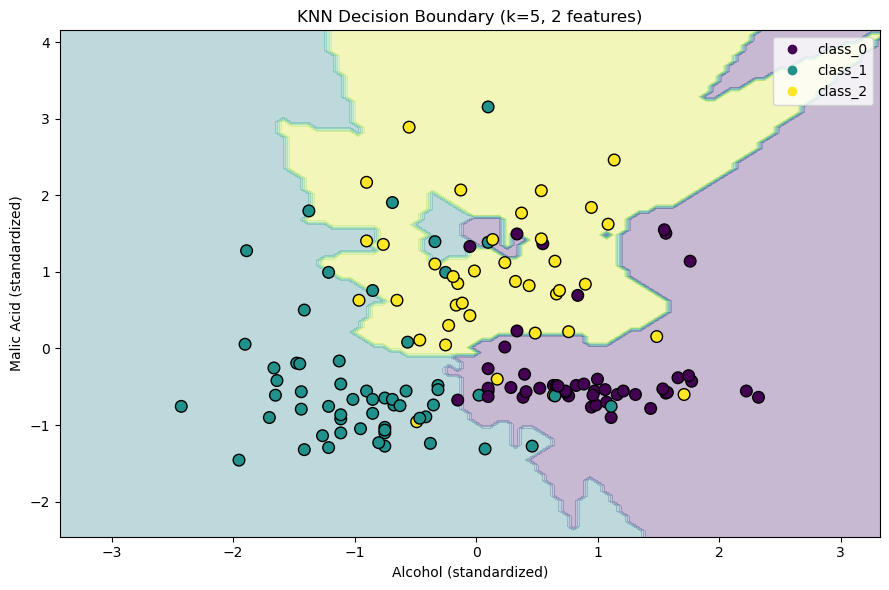

In [26]:
X_2d = X[:, :2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = sklearn_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y)

scaler_2d = StandardScaler().fit(X_train_2d)
X_train_2d_scaled = scaler_2d.transform(X_train_2d)

model_2d = KNN(k=5).fit(X_train_2d_scaled, y_train_2d)

x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1],
                      c=y_train_2d, cmap='viridis', edgecolors='k', s=70)
plt.xlabel('Alcohol (standardized)')
plt.ylabel('Malic Acid (standardized)')
plt.title('KNN Decision Boundary (k=5, 2 features)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(data.target_names))
plt.tight_layout()
plt.show()

## Discussion

- KNN achieves **97.22% accuracy** at k=1, 3, and 5 on the Wine dataset, and reaches **100% accuracy** for k=7 and above, demonstrating strong performance on this 13-feature chemical dataset
- The accuracy vs k plot shows an interesting pattern where performance improves and then stabilizes, unlike the Iris results where some middle k values dropped in accuracy
- This stability at 100% for larger k values suggests the Wine dataset is well clustered in feature space, meaning the 13 chemical features create natural separation between the three wine cultivars
- The **decision boundary visualization** uses only the first two features (Alcohol and Malic Acid) to allow 2D plotting, which explains why the boundary looks more complex and irregular than it would with all 13 features
- Class 1 concentrates on the left side where alcohol is lower, Class 0 dominates the lower right where alcohol is higher, and Class 2 appears in the upper middle where malic acid is higher
- The jagged and irregular boundaries are characteristic of KNN since predictions depend entirely on nearby training points rather than any smooth mathematical function
- Small pockets of one class inside another class's region show areas where the two chosen features overlap, but this would largely disappear if all 13 features were used
- Feature scaling was essential here since the 13 chemical features have very different ranges and units, and KNN uses Euclidean distance which is dominated by features with larger scales
- **Strengths** include no training phase, natural handling of multi-class problems, and strong performance on datasets with clear cluster structure like Wine
- **Weaknesses** include slow prediction time since every test point requires computing distances to all 178 training points, and sensitivity to irrelevant features